---
# ***PROBLEME DE DETECTION DES FARUDES BANCAIRE AU CONGO***
---

## 1 BUSINESS ANDERTANDING
### `OBJECTIF`: Detecter les farudes dans les transaction au mileu bancaire au congo.
- `Partie A`: Appliquer les modèles de Machine Learning supervisé pour determiner tous les cas des transaction fraudileuses dans la banque.
- `Mdèles`: Randam Forest et XGboost pour classifier les transaction fraudileuses ou non.
- `Partie B`: Appliquer le modèle de Machine Learning non supervisé pour permettre d'isolé les cas fraudileuses.
- `Mdèles`: Isolation Forest est le mieux pour gerrer ce cas de figure.
  * `Target`: es_fraude
  * `Features`: 'transaction_id', 'client_id', 'date_transaction', 'montant', 'devise',
                'type_transaction', 'canal', 'ville', 'marchand', 'est_fraude',

## 2 COMPREHENSION DES DONNÉES

In [1]:
# Les librairies de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librairies de machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier

# Test de Chi2 pour les variables catégorielles
from scipy.stats import chi2_contingency

# La selection des modèles
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

# Pipeline pour eviter les fuites des données
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Les metriques des modèles
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

In [2]:
# Lecture des données
df = pd.read_csv("detection_fraude_bancaire_congo_brazzaville.csv", index_col=False)
df

,transaction_id,client_id,date_transaction,montant,devise,type_transaction,canal,ville,marchand,est_fraude,type_fraude
0,1,9738,2024-06-10T11:22:02,15047,XAF,Virement,Distributeur (GAB),Ouesso,NaN,0,NaN
1,2,1957,2024-08-27T01:31:23,124572,XAF,Virement,TPE marchand,Brazzaville,Hôtel Radisson Blu,0,NaN
2,3,7654,2024-06-17T00:26:46,111019,XAF,Achat en ligne,Agence,Ouesso,Jumia,0,NaN
3,4,1638,2024-04-24T19:50:29,12461,XAF,Paiement,Distributeur (GAB),Nkayi,Score,0,NaN
4,5,1,2024-03-07T14:58:18,16578,XAF,Retrait,Mobile Banking,Brazzaville,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,9373,2024-06-16T19:57:41,5253,XAF,Dépôt,Internet Banking,Ouesso,NaN,0,NaN
99996,99997,1560,2024-03-16T11:24:27,9178,XAF,Transfert mobile,Mobile Money,Brazzaville,NaN,0,NaN
99997,99998,6245,2024-03-20T12:36:20,17223,XAF,Achat en ligne,Distributeur (GAB),Dolisie,Total Énergies,0,NaN
99998,99999,6454,2024-08-25T12:39:55,194489,XAF,Achat en ligne,Distributeur (GAB),Pointe-Noire,Score,0,NaN


In [3]:
# Liste des colonnes de mon dataset
df.columns

Index(['transaction_id', 'client_id', 'date_transaction', 'montant', 'devise',
       'type_transaction', 'canal', 'ville', 'marchand', 'est_fraude',
       'type_fraude'],
      dtype='object')

In [4]:
# Voir les types des données de mon dataset
df.dtypes

transaction_id       int64
client_id            int64
date_transaction    object
montant              int64
devise              object
type_transaction    object
canal               object
ville               object
marchand            object
est_fraude           int64
type_fraude         object
dtype: object

In [5]:
# Voir les differentes informations de mon dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   transaction_id    100000 non-null  int64 
 1   client_id         100000 non-null  int64 
 2   date_transaction  100000 non-null  object
 3   montant           100000 non-null  int64 
 4   devise            100000 non-null  object
 5   type_transaction  100000 non-null  object
 6   canal             100000 non-null  object
 7   ville             100000 non-null  object
 8   marchand          48149 non-null   object
 9   est_fraude        100000 non-null  int64 
 10  type_fraude       1028 non-null    object
dtypes: int64(4), object(7)
memory usage: 8.4+ MB


## 3 DATA CLEANING (NETTOYAGE DES DONNÉES ET SUPRESSION DES COLONNES INUTILLES)

In [6]:
# Voir les valeurs nulles
df.isna().sum()/df.shape[0]

transaction_id      0.00000
client_id           0.00000
date_transaction    0.00000
montant             0.00000
devise              0.00000
type_transaction    0.00000
canal               0.00000
ville               0.00000
marchand            0.51851
est_fraude          0.00000
type_fraude         0.98972
dtype: float64

In [7]:
df['date_transaction'] = pd.to_datetime(df['date_transaction'])
df['heure'] = df['date_transaction'].dt.hour
df['jour_semaine'] = df['date_transaction'].dt.dayofweek
# Ensuite tu peux supprimer 'date_transaction'

In [8]:
# Supression des colonnes "marchand" et "type_fraude"
df = df.drop(["marchand","type_fraude","transaction_id","client_id","devise","date_transaction"], axis=1)
df

,montant,type_transaction,canal,ville,est_fraude,heure,jour_semaine
0,15047,Virement,Distributeur (GAB),Ouesso,0,11,0
1,124572,Virement,TPE marchand,Brazzaville,0,1,1
2,111019,Achat en ligne,Agence,Ouesso,0,0,0
3,12461,Paiement,Distributeur (GAB),Nkayi,0,19,2
4,16578,Retrait,Mobile Banking,Brazzaville,0,14,3
...,...,...,...,...,...,...,...
99995,5253,Dépôt,Internet Banking,Ouesso,0,19,6
99996,9178,Transfert mobile,Mobile Money,Brazzaville,0,11,5
99997,17223,Achat en ligne,Distributeur (GAB),Dolisie,0,12,2
99998,194489,Achat en ligne,Distributeur (GAB),Pointe-Noire,0,12,6


## 4 EXPLORATORY DATA ANALYSIS 

* Analyse univarié des variables catégorielles

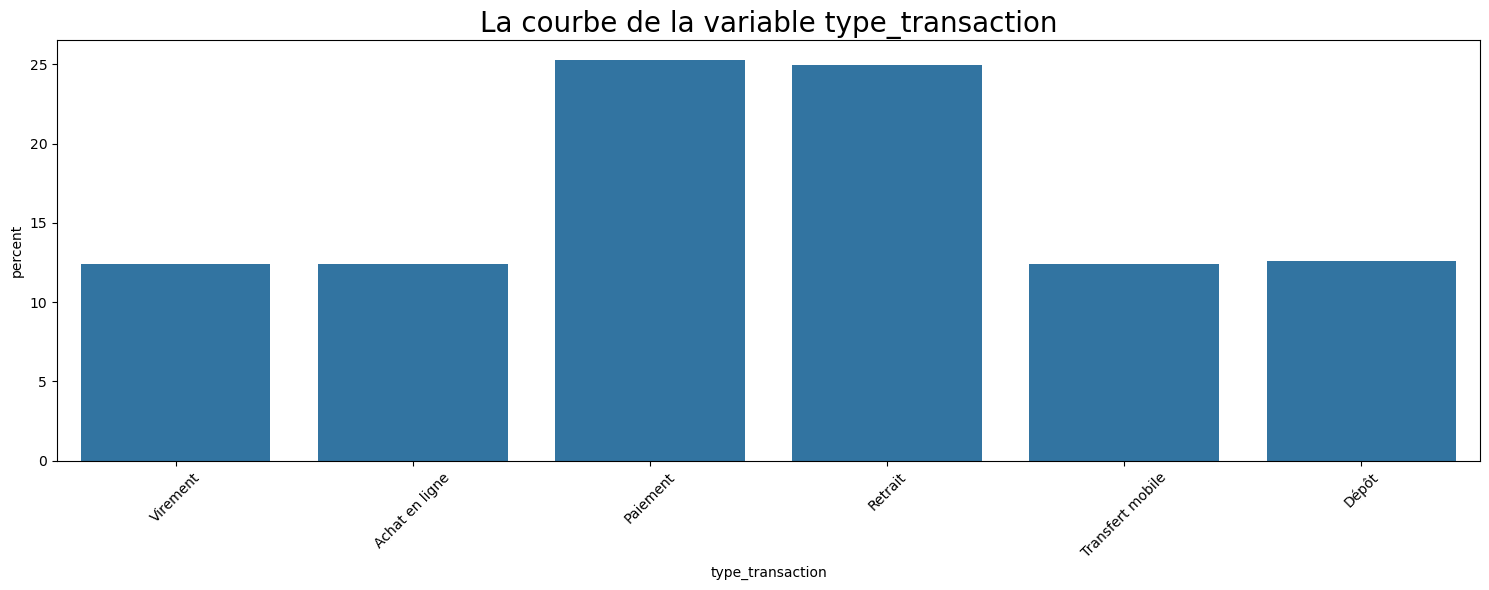

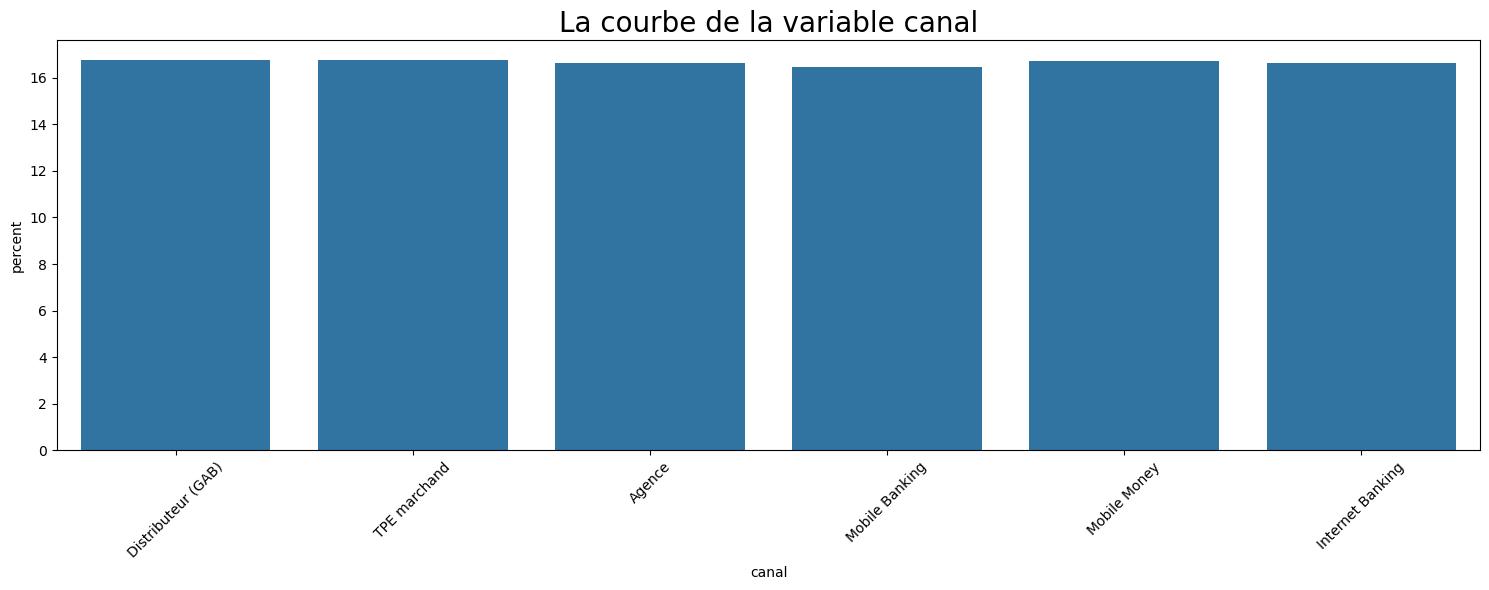

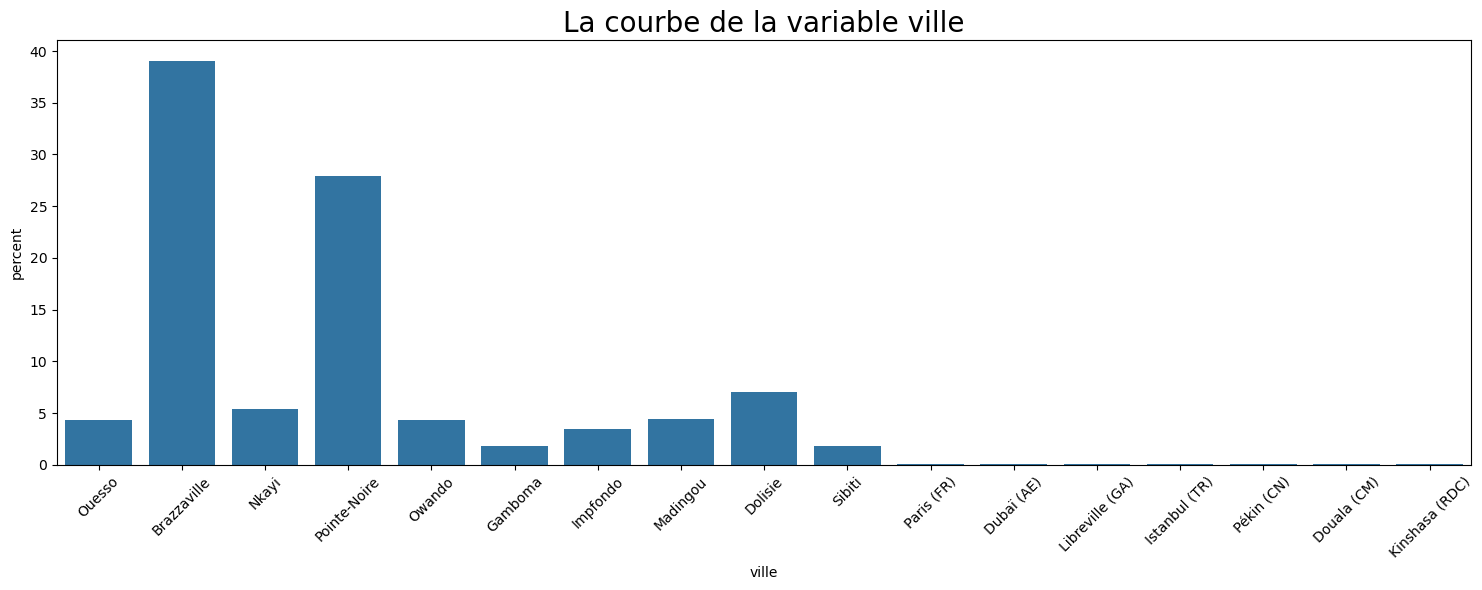

In [9]:
# Voir les variables catégorielles dans un countplot
for col in df.select_dtypes("object"):
    plt.figure(figsize=(15,6))
    sns.countplot(data=df,x=col,stat="percent")
    plt.title(f"La courbe de la variable {col}", fontsize=20)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<Figure size 1500x600 with 0 Axes>

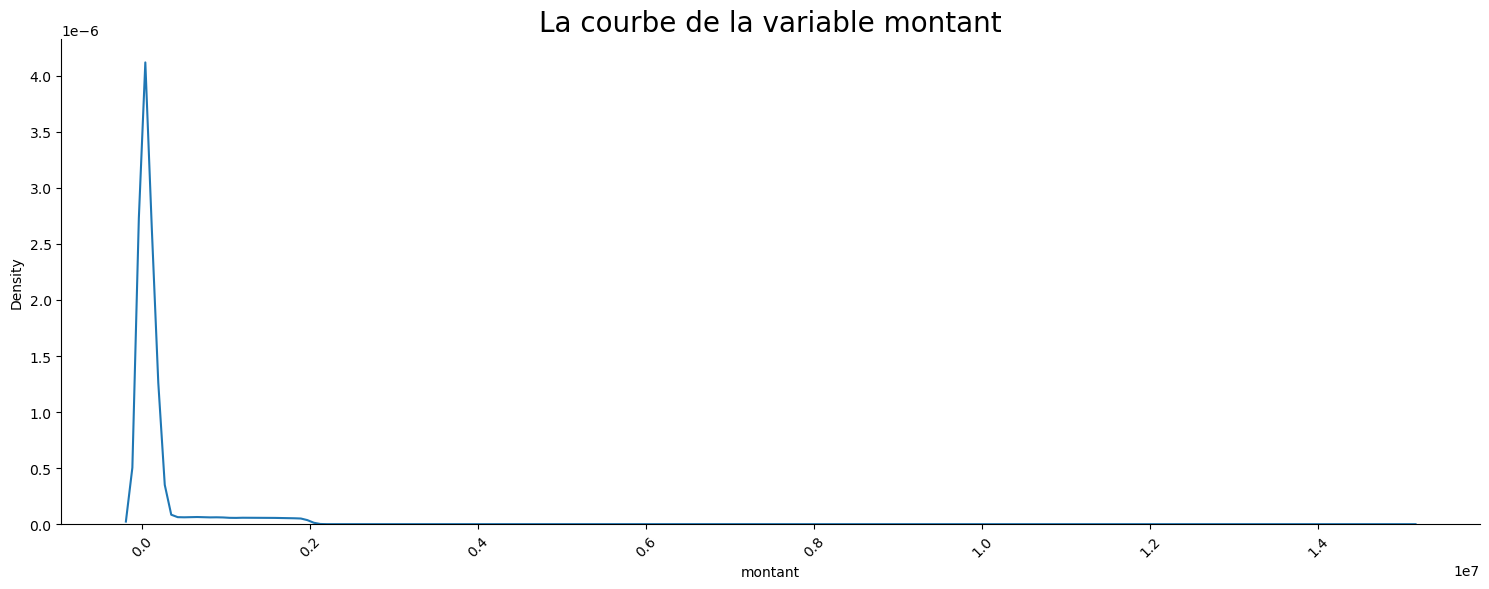

<Figure size 1500x600 with 0 Axes>

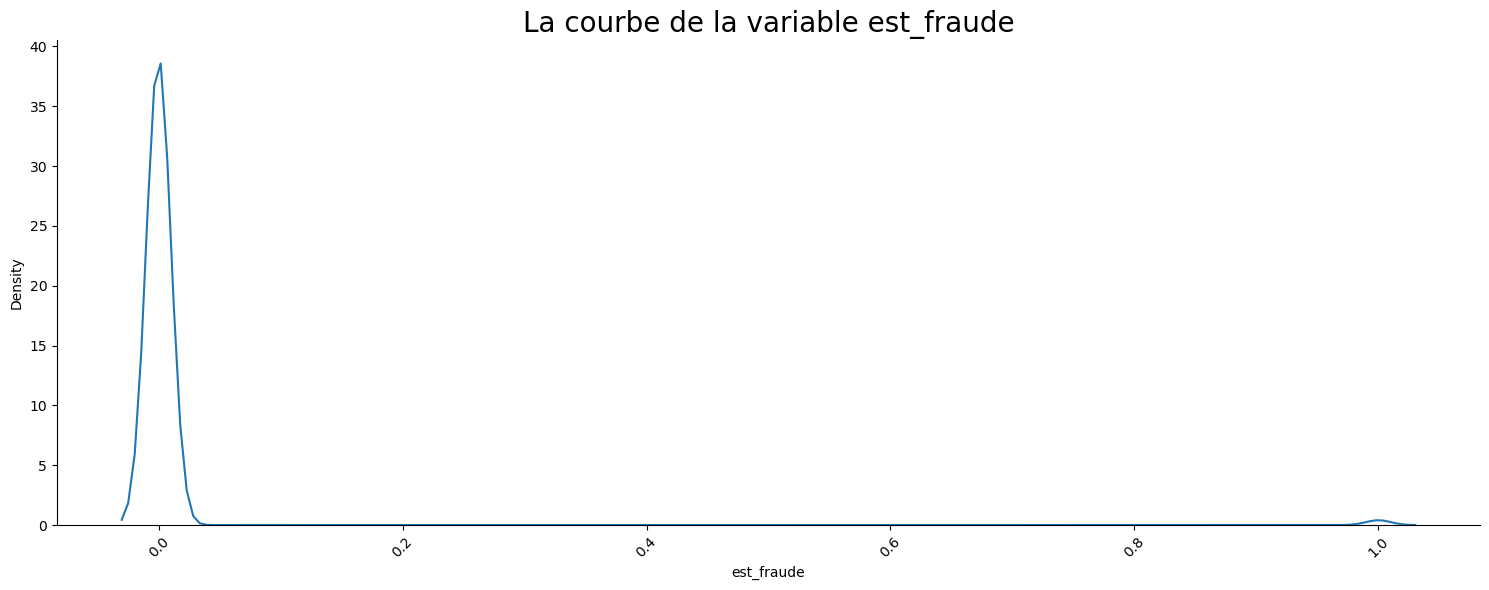

<Figure size 1500x600 with 0 Axes>

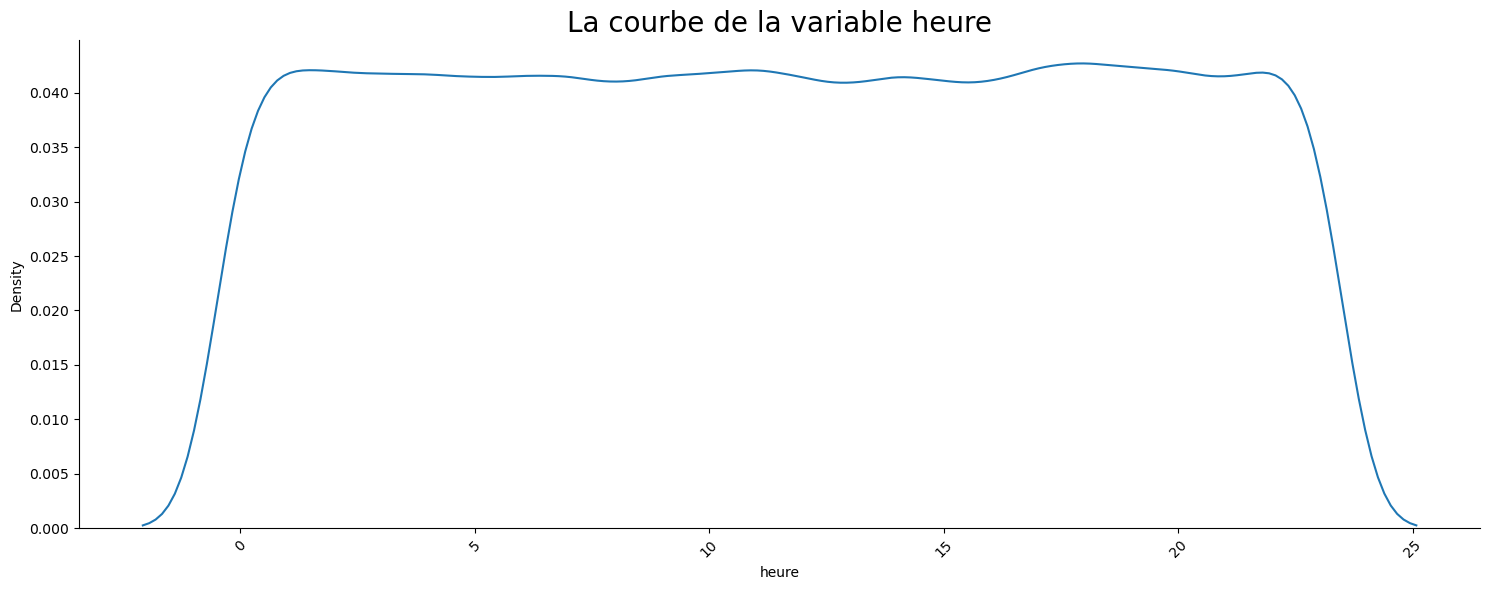

<Figure size 1500x600 with 0 Axes>

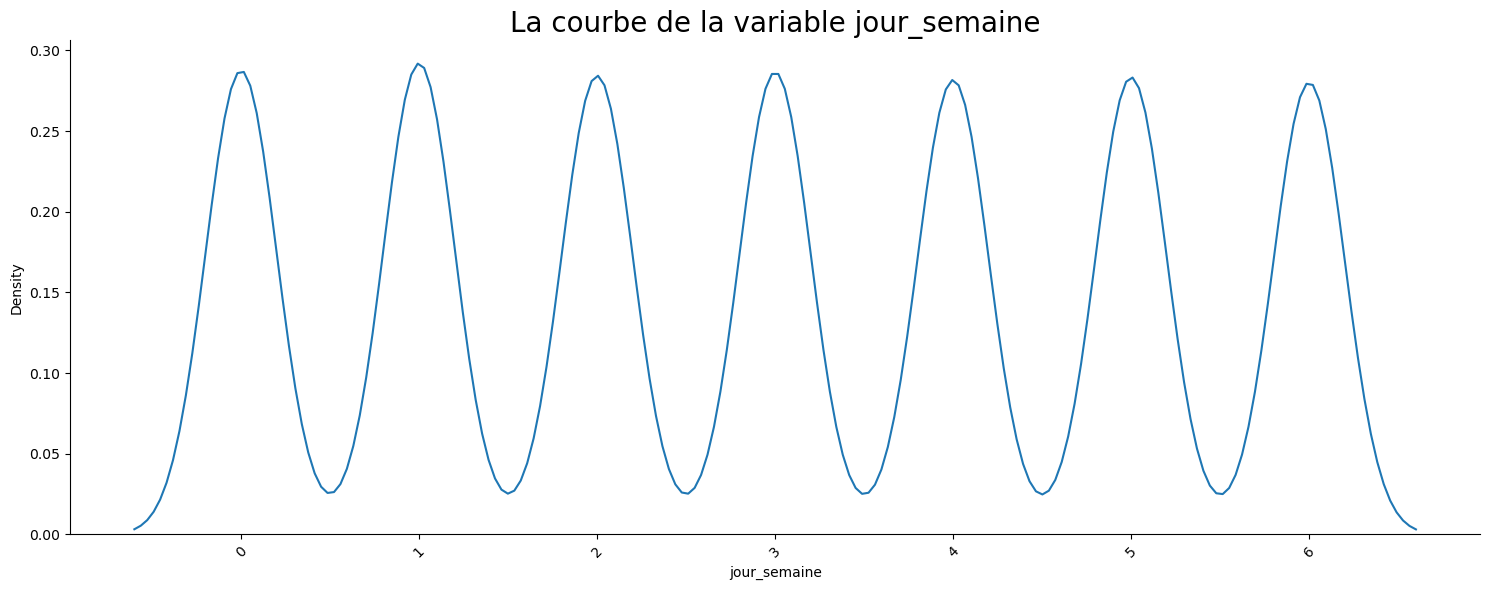

In [10]:
# Voir les variables numériques 
for col in df.select_dtypes("number"):
    plt.figure(figsize=(15,6))
    sns.displot(data=df, x=col, kind="kde", height=6, aspect=15/6)
    plt.title(f"La courbe de la variable {col}", fontsize=20)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

* Analyse bivariées des variables catégorielles

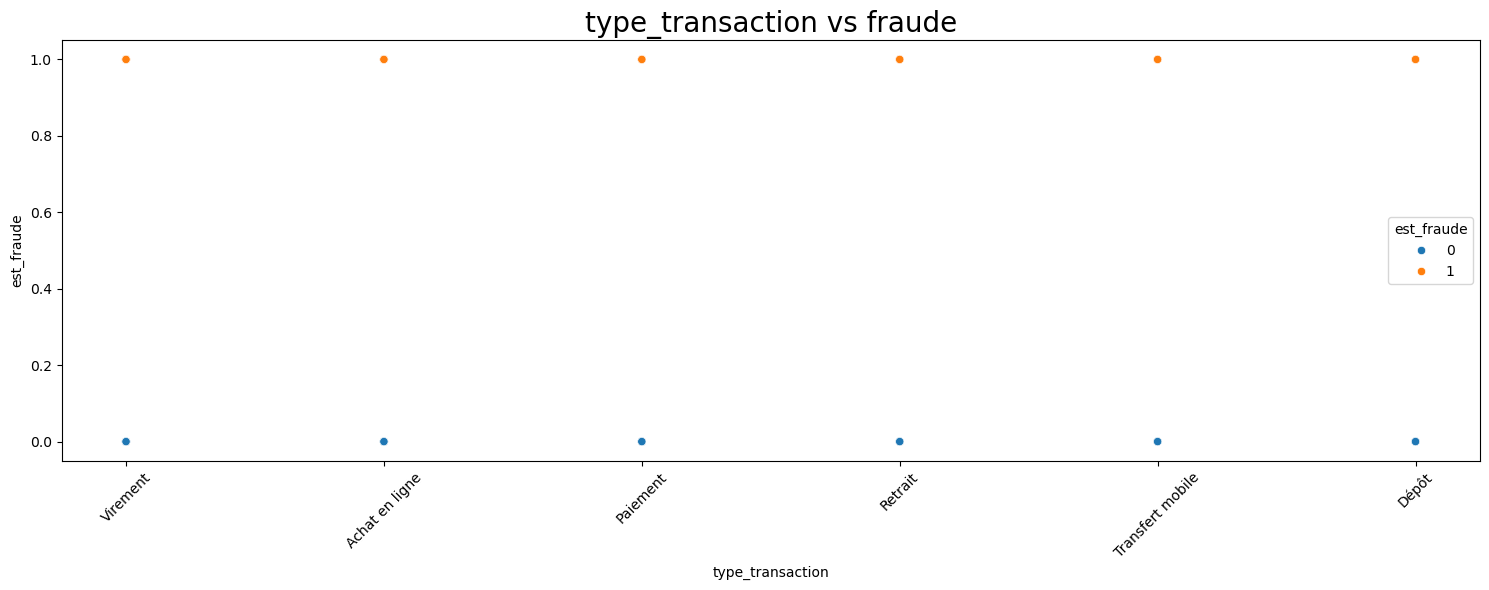

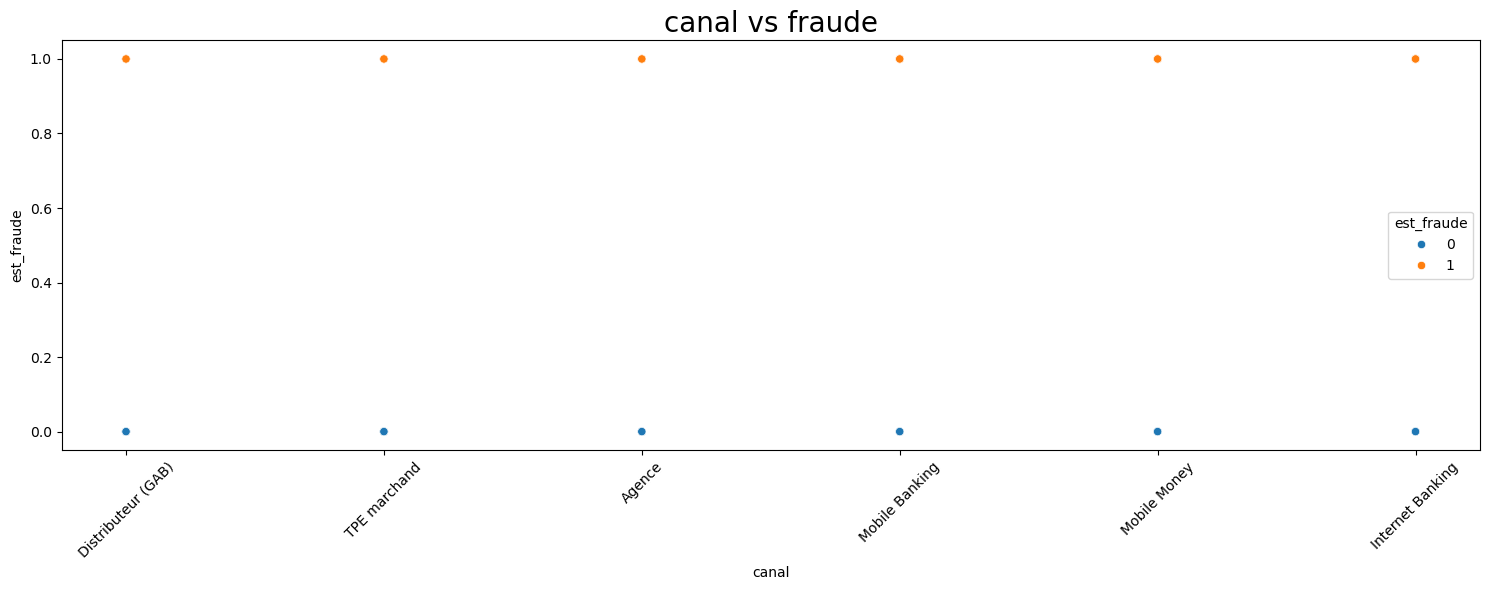

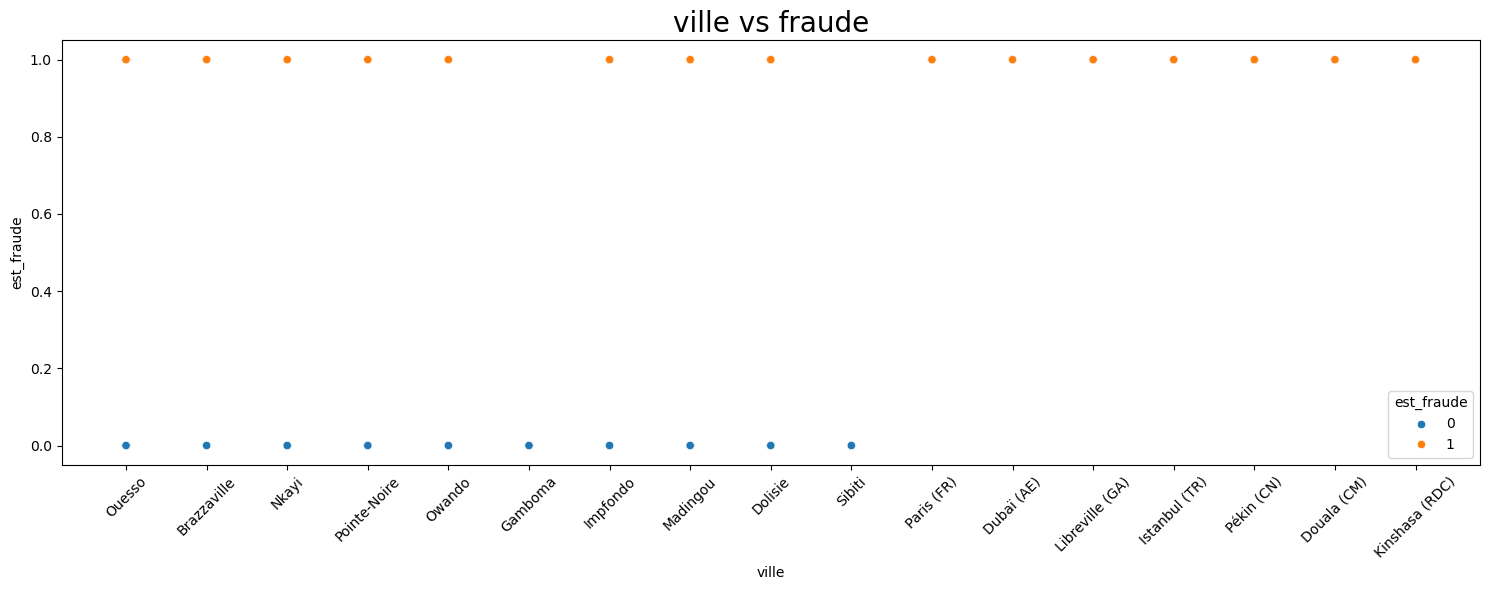

In [11]:
# Voir les variables catégorielles 
for col in df.select_dtypes("object").columns:
    plt.figure(figsize=(15,6))
    sns.scatterplot(data=df, x=col, y="est_fraude",hue="est_fraude")
    plt.title(f"{col} vs fraude", fontsize=20)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

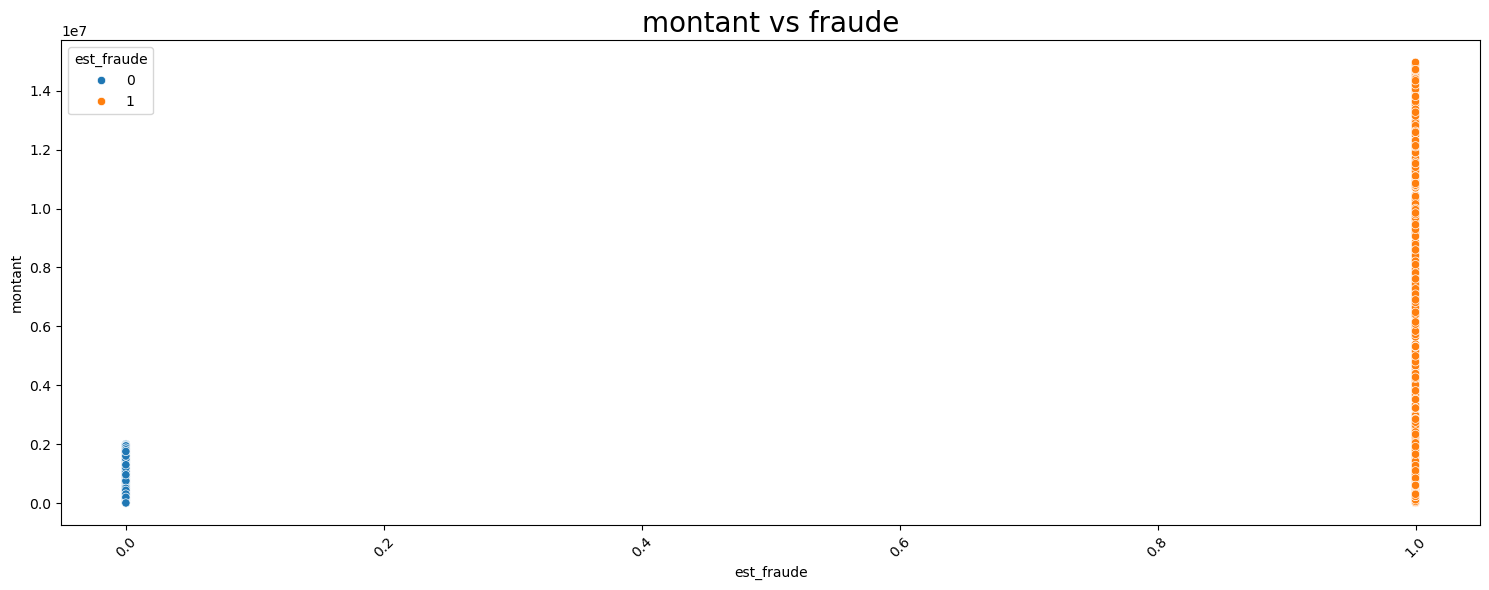

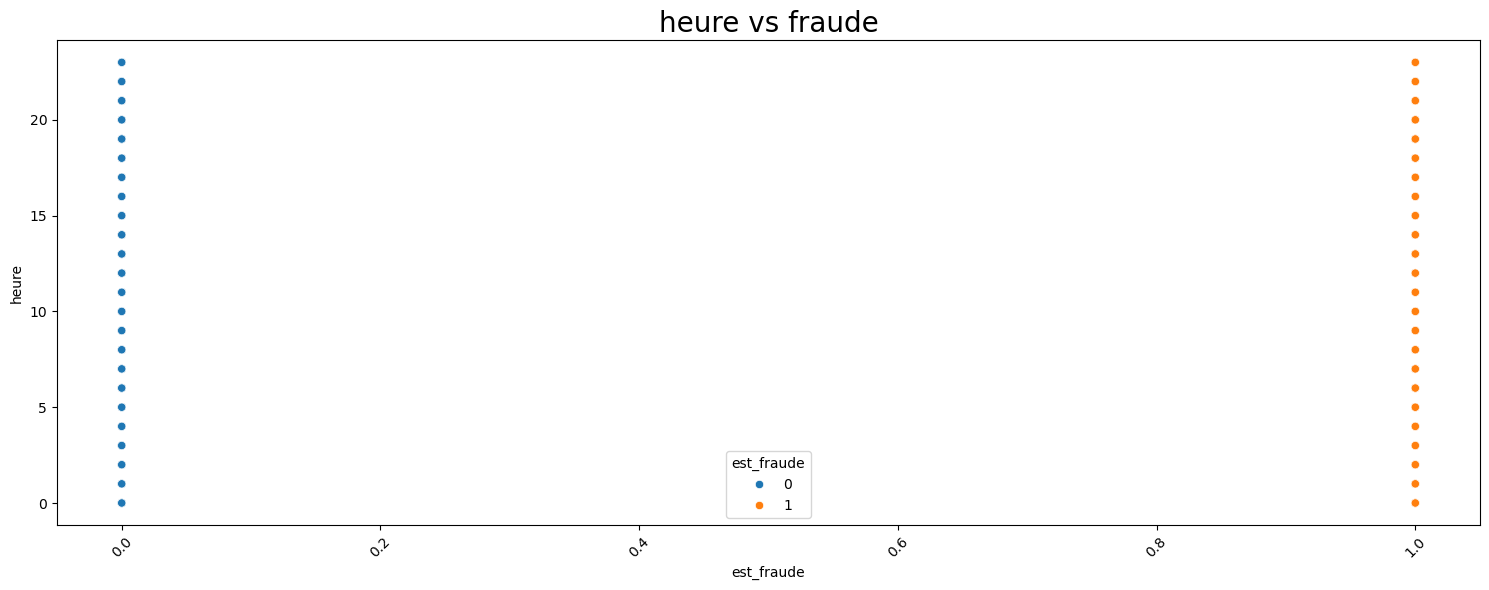

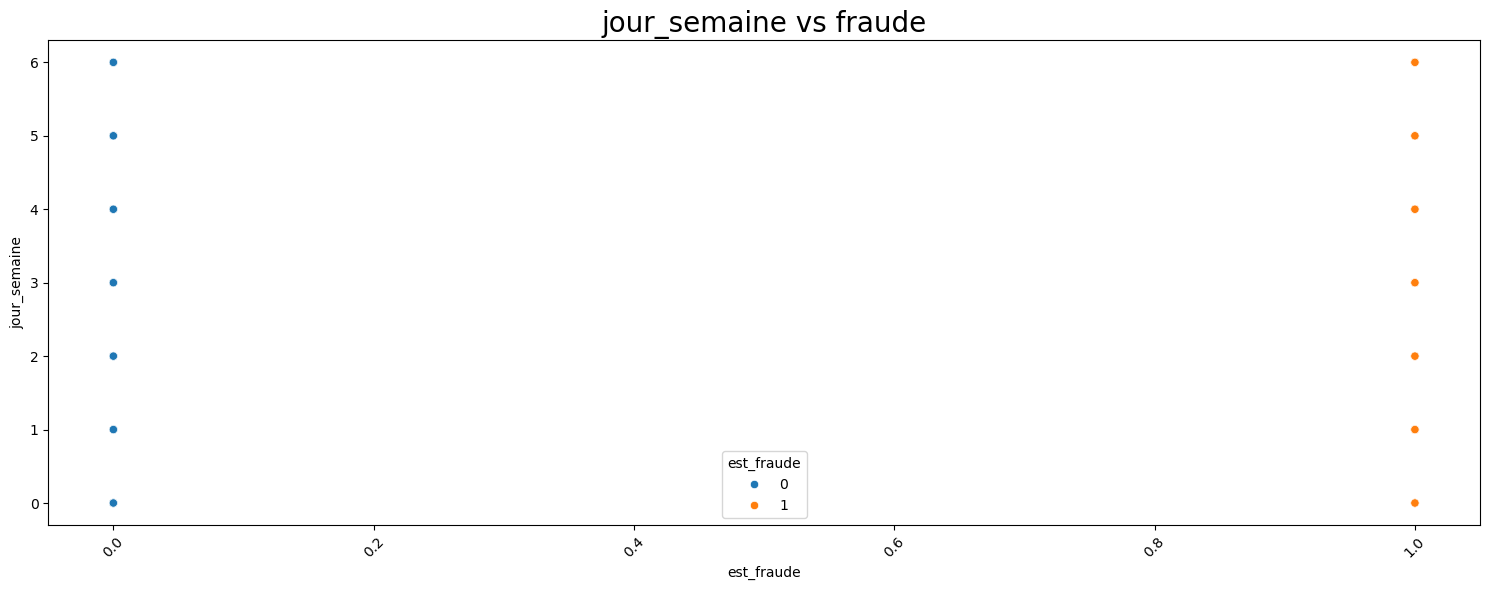

In [12]:
# Visualiser les variables numériques vs la cible
for col in df.select_dtypes("number").drop("est_fraude", axis=1):
    plt.figure(figsize=(15,6))
    sns.scatterplot(data=df, x="est_fraude", y=col, hue="est_fraude")
    plt.title(f"{col} vs fraude", fontsize=20)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
# La corrélation de Pearson
df_cor = df.select_dtypes("number").corr()
df_cor

,montant,est_fraude,heure,jour_semaine
montant,1.000000,0.451394,-0.005735,-0.004352
est_fraude,0.451394,1.000000,0.002592,-0.002795
heure,-0.005735,0.002592,1.000000,-0.000687
jour_semaine,-0.004352,-0.002795,-0.000687,1.000000


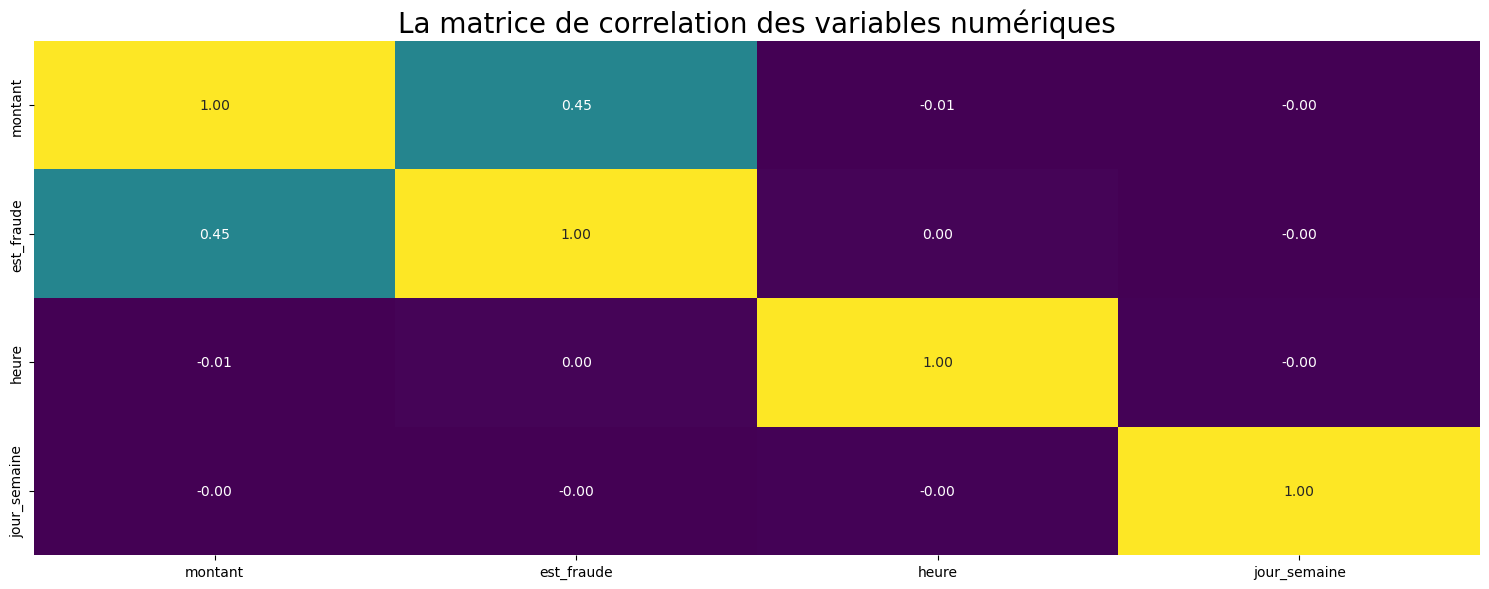

In [14]:
# La matrice de corrélation
plt.figure(figsize=(15,6))
sns.heatmap(data=df_cor,cmap="viridis",cbar=False,fmt=".2f",annot=True)
plt.title("La matrice de correlation des variables numériques", fontsize=20)
plt.tight_layout()
plt.show()

In [15]:
# Les tests statistiques 
resultat = []
for col in df.select_dtypes("object"):
    table = pd.crosstab(df[col],df["est_fraude"])
    chi2,p,dof,expected = chi2_contingency(table)
    resultat.append({
        "Variables":col,
        "Test":"Chi²",
        "Chi2":round(chi2,4),
        "DDL":round(dof,4),
        "Expected":round(expected.min(), 4),
        "P_value":round(p,4),
        "Significatif": "variable corréléé" if p<0.05 else "variable non corrélée"})

df_chi2 = pd.DataFrame(resultat)
df_chi2

,Variables,Test,Chi2,DDL,Expected,P_value,Significatif
0,type_transaction,Chi²,2.3519,5,127.2150,0.7986,variable non corrélée
1,canal,Chi²,3.0526,5,169.4658,0.6919,variable non corrélée
2,ville,Chi²,48751.4865,16,0.5860,0.0000,variable corréléé


### `Conclusion`: Nous remarquons qu'il y a une corrélation des villes avec les transaction fraudileuses.

## 6 DATA PREPROCESSING 
### Partie A: Modèles supervisé

In [16]:
# Encoder les variables

df = pd.get_dummies(df, drop_first=True)
df = df.astype({col: int for col in df.select_dtypes(bool)})
df

,montant,est_fraude,heure,jour_semaine,type_transaction_Dépôt,type_transaction_Paiement,type_transaction_Retrait,type_transaction_Transfert mobile,type_transaction_Virement,canal_Distributeur (GAB),...,ville_Kinshasa (RDC),ville_Libreville (GA),ville_Madingou,ville_Nkayi,ville_Ouesso,ville_Owando,ville_Paris (FR),ville_Pointe-Noire,ville_Pékin (CN),ville_Sibiti
0,15047,0,11,0,0,0,0,0,1,1,...,0,0,0,0,1,0,0,0,0,0
1,124572,0,1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,111019,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,12461,0,19,2,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
4,16578,0,14,3,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,5253,0,19,6,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
99996,9178,0,11,5,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
99997,17223,0,12,2,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
99998,194489,0,12,6,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


In [17]:
# Séparation des données
X = df.drop("est_fraude", axis=1)
y = df["est_fraude"]

# La méthode splite dans ma dataset
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [18]:
# 3. Calcul dynamique du scale_pos_weight sur le jeu d'entraînement
num_negatifs = (y_train == 0).sum()
num_positifs = (y_train == 1).sum()
poids_optimal = num_negatifs / num_positifs

In [19]:
pip_rf = Pipeline([("scaler",StandardScaler()),("randomforest",RandomForestClassifier(class_weight='balanced'))])
pip_xg = Pipeline([("scaler",StandardScaler()),("xgboost", XGBClassifier(scale_pos_weight=poids_optimal))])

In [20]:
# Entraiment des modèles
pip_rf.fit(X_train,y_train)
pip_xg.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('xgboost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [21]:
# La validation croisé
pipe_list = [("randomfores",pip_rf),("xgboost",pip_xg)]
for name, pip in pipe_list:
    scores = cross_val_score(pip, X_train, y_train, cv=5)
    print(f"{name}: score = {scores.mean()}")

randomfores: score = 0.9962875
xgboost: score = 0.9759125


In [22]:
# Voir les scores des deux modèles
score_rf = pip_rf.score(X_test,y_test)
score_xg = pip_xg.score(X_test,y_test)

print(f"Le score du modèle randomforst = {score_rf}")
print(f"Le score du modèle xgboost = {score_xg:}")

Le score du modèle randomforst = 0.99585
Le score du modèle xgboost = 0.97245


In [23]:
# La prediction des modèles
y_rf = pip_rf.predict(X_test)
y_xg = pip_xg.predict(X_test)

In [24]:
# La matrice de cofusions et le calssification report
matrice_rf = confusion_matrix(y_test,y_rf)
matrice_xg = confusion_matrix(y_test,y_xg)

print(f"La matrice de confusion du modèle randomforst:\n {matrice_rf}")
print(f"La matrice de confusion du modèle xgboost:\n {matrice_xg}")

La matrice de confusion du modèle randomforst:
 [[19791     3]
 [   80   126]]
La matrice de confusion du modèle xgboost:
 [[19293   501]
 [   50   156]]


In [25]:
# La classification repport
class_rf = classification_report(y_test,y_rf)
class_xg = classification_report(y_test,y_xg)

print(f"Le report de classification du modèle randomforst:\n {class_rf}")
print(f"Le report de classification du modèle xgboost:\n {class_xg}")

Le report de classification du modèle randomforst:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19794
           1       0.98      0.61      0.75       206

    accuracy                           1.00     20000
   macro avg       0.99      0.81      0.88     20000
weighted avg       1.00      1.00      1.00     20000

Le report de classification du modèle xgboost:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     19794
           1       0.24      0.76      0.36       206

    accuracy                           0.97     20000
   macro avg       0.62      0.87      0.67     20000
weighted avg       0.99      0.97      0.98     20000



## 7 Hyperparametre

In [26]:
# 1. Tes pipelines (assure-toi que l'étape du modèle s'appelle bien 'randomforest' et 'xgboost')
pipelines = {
    "randomforest": pip_rf, 
    "xgboost": pip_xg
}

# 2. La Grille de paramètres corrigée (on retire la clé intermédiaire)
param_grid = {
    "randomforest": {
        "randomforest__n_estimators": [100, 200],
        "randomforest__max_depth": [3, 5, 10]
    },
    "xgboost": {
        "xgboost__n_estimators": [200, 300],
        "xgboost__max_depth": [3, 5],
        "xgboost__learning_rate": [0.01, 0.1]
    }
}

In [27]:
# La fonction grid search
for name, model in pipelines.items():
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid[name],
        cv=5,
        n_jobs=-1)
    grid.fit(X_train,y_train)
    print("\nLes meilleurs parametres sont:\n",grid.best_params_)
    print("\nLes meilleurs scores sont:\n",grid.best_score_)


Les meilleurs parametres sont:
 {'randomforest__max_depth': 10, 'randomforest__n_estimators': 200}

Les meilleurs scores sont:
 0.9276499999999999

Les meilleurs parametres sont:
 {'xgboost__learning_rate': 0.1, 'xgboost__max_depth': 5, 'xgboost__n_estimators': 300}

Les meilleurs scores sont:
 0.9587749999999999


## Partie B: Machine learning non supervisé

In [28]:
# Entrainement du modele
model = IsolationForest(contamination=0.02)
model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [29]:
y_pred = model.predict(X_test)

In [30]:
# Label
labels = y
# Silhouette score
score = silhouette_score(X,labels)
print("Silhouette Score :", score)

Silhouette Score : 0.9023213323641102


In [31]:
# Le davies
score = davies_bouldin_score(X,labels)
print("Davies-Bouldin :", score)

Davies-Bouldin : 1.3248635426595772


In [32]:
# Le caliski
score = calinski_harabasz_score(X,labels)
print("Calinski-Harabasz :", score)

Calinski-Harabasz : 25589.188689259994


In [33]:
# Afficher les variables "Sans anomalies" et "Les anomalies"
print("Sans anomalies :", np.sum(y_pred == 0))
print("Anomalies :", np.sum(y_pred == 1))

Sans anomalies : 0
Anomalies : 19587


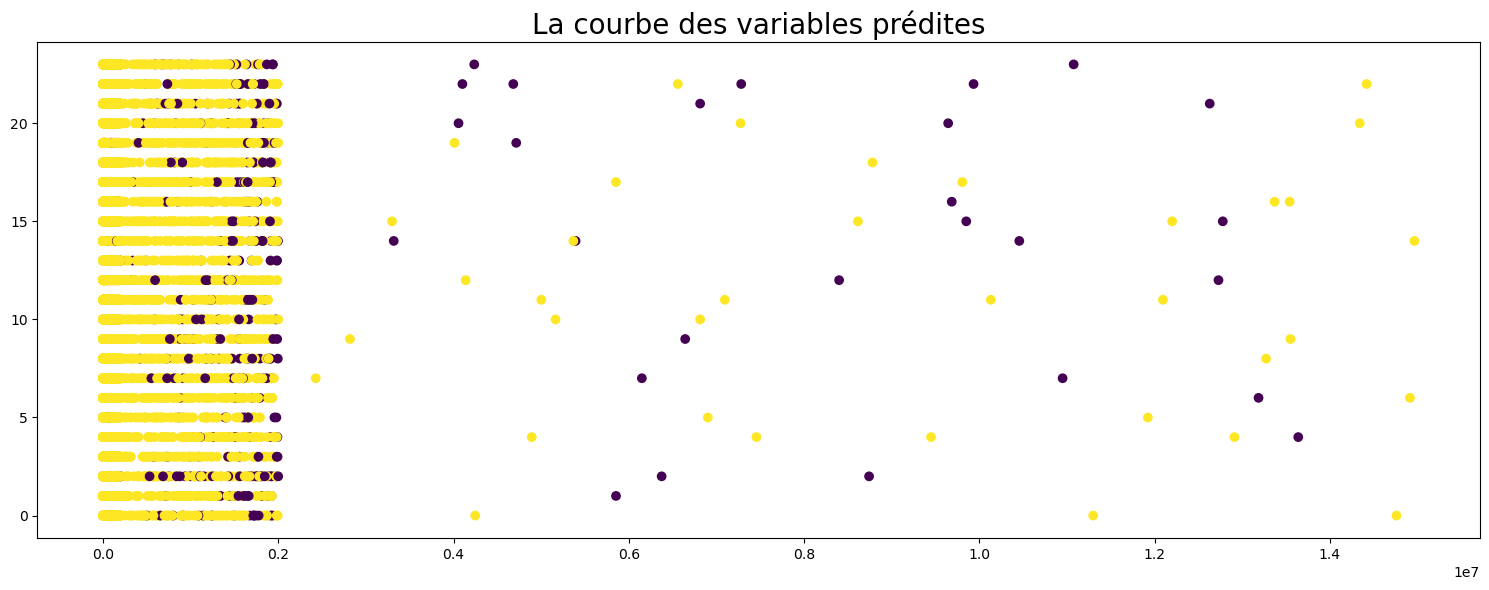

In [34]:
plt.figure(figsize=(15,6))
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_pred)
plt.title("La courbe des variables prédites", fontsize=20)
plt.tight_layout()
plt.show()